# Numerical Simulation Laboratory - Esercizio 12

## Keras: riconoscimento di cifre con DNN e CNN

In questa esercitazione studio il riconoscimento automatico delle cifre scritte a mano del dataset MNIST. Ogni immagine è in scala di grigi, ha dimensione $28 \times 28$ e rappresenta una cifra tra 0 e 9. Il problema è quindi una classificazione multiclasse: data un'immagine in input, la rete deve assegnarle una delle dieci possibili etichette.

L'esercizio è diviso in tre parti. Prima uso una rete fully connected, cioè una DNN, e confronto diversi ottimizzatori. Poi costruisco una rete convoluzionale (CNN) più adatta al trattamento di immagini. Infine provo la CNN su alcune cifre disegnate da me, per vedere quanto il modello riesca a generalizzare fuori dal dataset MNIST standard.


## Idea fisica e computazionale

Una rete fully connected tratta l'immagine come un vettore di $784$ numeri. Questo approccio è già abbastanza efficace su MNIST, perché le cifre sono centrate e il dataset è molto pulito. Tuttavia, appiattendo l'immagine si perde l'informazione geometrica: due pixel vicini nell'immagine non sono più trattati esplicitamente come pixel vicini.

Una CNN, invece, mantiene la struttura $28 \times 28$ dell'immagine. I filtri convoluzionali osservano piccole regioni locali e imparano a riconoscere elementi semplici, come bordi, tratti verticali, curve o incroci. I layer successivi combinano queste informazioni locali per arrivare alla classificazione finale.

Dal punto di vista concettuale, questa è l'idea più importante dell'esercizio: per dati con una struttura spaziale, come le immagini, conviene usare un modello che sfrutti questa struttura invece di ignorarla.


## Import, seed e stile dei grafici

In [1]:
import os
import warnings
# Riduce i messaggi informativi prodotti da TensorFlow.

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.utils import to_categorical

# Seed per rendere il confronto il più riproducibile possibile.
seed = 0
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Impostazioni generali per grafici più leggibili.
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

I0000 00:00:1783417869.989122 1370928 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783417870.871991 1370928 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Caricamento e preprocessing del dataset MNIST

Carico il dataset MNIST e preparo due versioni degli stessi dati. Per la DNN uso immagini appiattite in vettori di lunghezza $784$, mentre per la CNN conservo la forma bidimensionale $28 \times 28 \times 1$.

Le label originali sono numeri interi tra $0$ e $9$. Per esempio, se un'immagine rappresenta la cifra $4$, la sua label è semplicemente `4`. Siccome però il layer finale della rete produce dieci probabilità, una per ogni possibile cifra, conviene trasformare anche la label in un vettore di dieci componenti. Questa rappresentazione si chiama one-hot encoding: tutte le componenti sono nulle tranne quella corrispondente alla classe corretta.

Per esempio, la cifra $4$ diventa

$$
[0,0,0,0,1,0,0,0,0,0].
$$

In questo modo l'output della rete e la label hanno la stessa struttura: entrambi sono vettori di lunghezza $10$. La rete produce una distribuzione di probabilità sulle dieci classi, mentre la label one-hot indica quale dovrebbe essere la classe corretta.


In [2]:
img_rows, img_cols = 28, 28
num_classes = 10

(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

# Input per la DNN: immagini appiattite in vettori di 784 pixel.
X_train_DNN = X_train_raw.reshape(X_train_raw.shape[0], img_rows * img_cols).astype("float32") / 255.0
X_test_DNN = X_test_raw.reshape(X_test_raw.shape[0], img_rows * img_cols).astype("float32") / 255.0

# Input per la CNN: immagini mantenute nel formato 28 x 28 x 1.
X_train_CNN = X_train_raw.reshape(X_train_raw.shape[0], img_rows, img_cols, 1).astype("float32") / 255.0
X_test_CNN = X_test_raw.reshape(X_test_raw.shape[0], img_rows, img_cols, 1).astype("float32") / 255.0

# Label in formato one-hot, necessario per categorical_crossentropy.
Y_train = to_categorical(y_train, num_classes)
Y_test = to_categorical(y_test, num_classes)

print("X_train_DNN:", X_train_DNN.shape)
print("X_test_DNN: ", X_test_DNN.shape)
print("X_train_CNN:", X_train_CNN.shape)
print("X_test_CNN: ", X_test_CNN.shape)
print("Y_train:    ", Y_train.shape)
print("Y_test:     ", Y_test.shape)

X_train_DNN: (60000, 784)
X_test_DNN:  (10000, 784)
X_train_CNN: (60000, 28, 28, 1)
X_test_CNN:  (10000, 28, 28, 1)
Y_train:     (60000, 10)
Y_test:      (10000, 10)


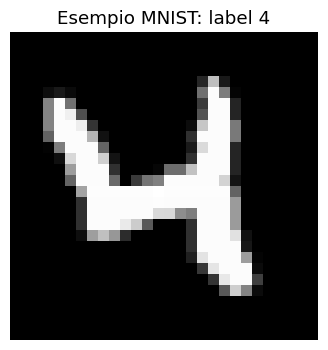

Label one-hot: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [3]:
indice = 20

plt.figure(figsize=(4, 4))
plt.imshow(X_train_raw[indice], cmap="gray")
plt.title(f"Esempio MNIST: label {y_train[indice]}")
plt.axis("off")
plt.show()

print("Label one-hot:", Y_train[indice])

# Esercizio 12.1 - DNN e confronto tra ottimizzatori

La prima richiesta dell'esercizio è partire da una rete fully connected e aumentare il numero di epoche rispetto all'esempio base della consegna. In questa parte uso sempre la stessa architettura e cambio solo l'ottimizzatore, così il confronto rimane pulito: eventuali differenze nei risultati dipendono soprattutto dal metodo usato per aggiornare i pesi.

Durante il training la rete modifica i propri parametri per minimizzare la funzione di costo. In forma schematica, un aggiornamento dei pesi può essere scritto come

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta L,
$$

dove $\theta$ indica i parametri del modello, $L$ è la loss e $\eta$ è il learning rate. L'ottimizzatore stabilisce come usare il gradiente per aggiornare i pesi. Quindi non cambia l'architettura della rete, ma cambia il modo in cui la rete cerca il minimo della loss.

Confronto tre casi. `SGD` è il metodo più diretto: aggiorna i pesi seguendo il gradiente stimato sui mini-batch. È semplice e robusto, ma può convergere lentamente e dipende molto dalla scelta del learning rate. `RMSprop` è un metodo adattivo: tiene conto della scala recente dei gradienti e modifica il passo effettivo in modo diverso per i vari parametri. `Adam` combina un'idea simile a RMSprop con una media del gradiente, quindi introduce anche un effetto simile al momento. Per questo motivo spesso converge più rapidamente di SGD.

Va tenuto presente che un singolo training non è una prova statistica definitiva. L'inizializzazione dei pesi, l'ordine dei batch e il learning rate possono modificare leggermente i risultati. Per lo scopo dell'esercizio, però, il confronto è sufficiente per capire il comportamento dei diversi ottimizzatori.


## Architettura DNN

La DNN riceve in ingresso un vettore di $784$ pixel. Ho scelto tre layer densi con dimensione decrescente, $200 \rightarrow 100 \rightarrow 50$, seguiti da un dropout e dal layer finale di classificazione. Il dropout serve a ridurre l'overfitting: durante il training spegne casualmente una parte dei neuroni, obbligando la rete a non dipendere troppo da singole attivazioni.

Il layer finale ha 10 neuroni e attivazione `softmax`, quindi restituisce una distribuzione di probabilità sulle dieci cifre.


In [4]:
def crea_DNN():
    model = Sequential(name="mnist_DNN")
    model.add(Input(shape=(img_rows * img_cols,)))
    model.add(Dense(200, activation="relu"))
    model.add(Dense(100, activation="relu"))
    model.add(Dense(50, activation="relu"))
    model.add(Dropout(0.5))
    # Layer di Output
    model.add(Dense(num_classes, activation="softmax"))
    return model


modello_DNN_esempio = crea_DNN()
modello_DNN_esempio.summary()

E0000 00:00:1783417871.413609 1370928 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "mnist_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,660 (713.52 KB)

 Trainable params: 182,660 (713.52 KB)

 Non-trainable params: 0 (0.00 B)

## Training della DNN con diversi ottimizzatori

Qui addestro tre DNN identiche, una per ogni ottimizzatore. Per rendere il confronto più controllato, prima di ogni training fisso di nuovo i seed e creo il modello da zero. In questo modo ogni ottimizzatore parte dalla stessa situazione iniziale.

Uso `categorical_crossentropy` come funzione di costo, perché il problema è una classificazione multiclasse con label in formato one-hot. Se indico con $y_i$ la label vera della classe $i$ e con $\hat{y}_i$ la probabilità predetta dalla rete, la categorical cross entropy è

$$
L = - \sum_{i=0}^{9} y_i \log(\hat{y}_i).
$$

Nel caso MNIST ogni immagine appartiene a una sola classe: ad esempio, per una cifra $3$, il vettore vero ha valore $1$ nella posizione corrispondente al $3$ e $0$ in tutte le altre. Per questo motivo nella somma rimane attivo solo il termine della classe corretta. Minimizzare questa loss significa quindi aumentare la probabilità assegnata dalla rete alla cifra giusta.

Come metrica considero l'accuracy, cioè la frazione di immagini classificate correttamente. L'accuracy è facile da interpretare, ma durante il training è più utile minimizzare la cross entropy, perché tiene conto anche di quanto la rete è sicura della propria predizione.

I learning rate scelti sono valori standard: $0.01$ per `SGD`, che non adatta automaticamente il passo, e $0.001$ per `Adam` e `RMSprop`, che invece modificano internamente la scala degli aggiornamenti. Non sono dunque learning rate ottimali in assoluto, ma una scelta ragionevole per confrontare i metodi richiesti.

La tabella finale riporta loss e accuracy sia sul training set sia sul test set. La quantità più importante è la test accuracy, perché misura la capacità del modello di classificare immagini non usate per aggiornare i pesi.


In [5]:
batch_size_DNN = 125
epochs_DNN = 15

# Lista degli ottimizzatori da confrontare.
ottimizzatori_DNN = [
    ("SGD", SGD(learning_rate=0.01)),
    ("Adam", Adam(learning_rate=0.001)),
    ("RMSprop", RMSprop(learning_rate=0.001)),
]

models_DNN = {}
histories_DNN = {}
risultati_DNN = []

# Ciclo sui tre ottimizzatori.
for nome_ottimizzatore, ottimizzatore in ottimizzatori_DNN:
    print(f"\nTraining DNN con ottimizzatore: {nome_ottimizzatore}")

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = crea_DNN()

    # Compilo il modello, cioè specifico:
    model.compile(
        loss="categorical_crossentropy",
        optimizer=ottimizzatore,
        metrics=["accuracy"],
    )

    # Addestramento della rete.
    history = model.fit(
        X_train_DNN,
        Y_train,
        batch_size=batch_size_DNN,
        epochs=epochs_DNN,
        validation_data=(X_test_DNN, Y_test),
        shuffle=True,
        verbose=0,
    )

    # Valuto il modello finale sul training set.
    train_loss, train_accuracy = model.evaluate(X_train_DNN, Y_train, verbose=0)

    # Valuto il modello finale sul test set.
    test_loss, test_accuracy = model.evaluate(X_test_DNN, Y_test, verbose=0)

    # Salvo il modello addestrato nel dizionario.
    models_DNN[nome_ottimizzatore] = model
    
    histories_DNN[nome_ottimizzatore] = history

    risultati_DNN.append({
        "ottimizzatore": nome_ottimizzatore,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    })



risultati_DNN = pd.DataFrame(risultati_DNN)
risultati_DNN


Training DNN con ottimizzatore: SGD

Training DNN con ottimizzatore: Adam

Training DNN con ottimizzatore: RMSprop


,ottimizzatore,train_loss,train_accuracy,test_loss,test_accuracy
0,SGD,0.159121,0.952633,0.162714,0.9484
1,Adam,0.009407,0.997133,0.115088,0.9812
2,RMSprop,0.019278,0.995017,0.154202,0.9769


## Grafici di loss e accuracy per la DNN

I grafici permettono di seguire l'intero andamento del training, non solo il valore finale. In particolare controllo se la loss diminuisce in modo regolare, se l'accuracy si stabilizza e se compare una separazione evidente tra training e validation/test.


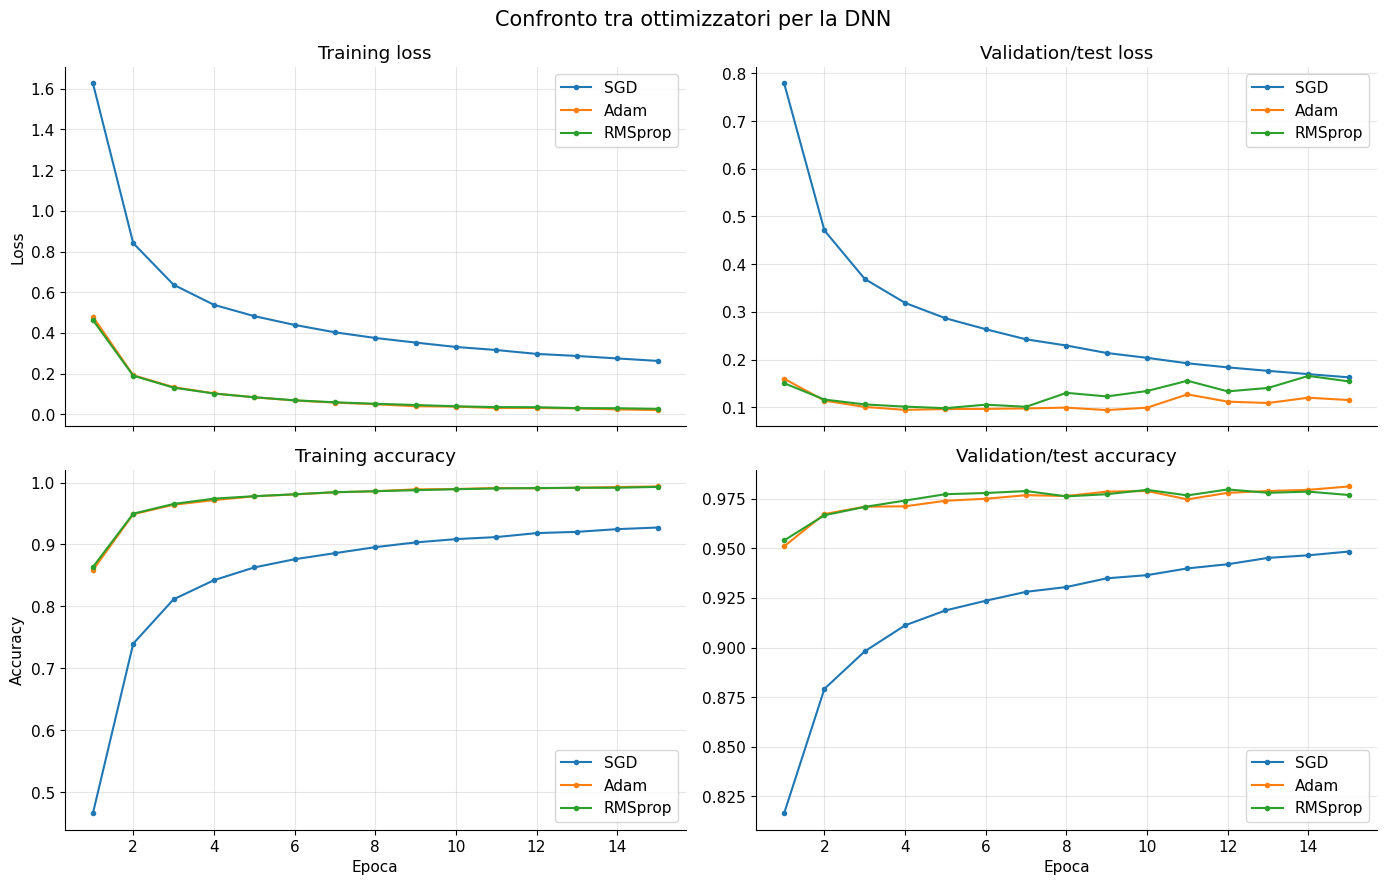

In [6]:
def plot_confronto_storie(histories, titolo):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

    for nome, history in histories.items():
        epoche = np.arange(1, len(history.history["loss"]) + 1)

        axes[0, 0].plot(epoche, history.history["loss"], marker="o", markersize=3, label=nome)
        axes[0, 1].plot(epoche, history.history["val_loss"], marker="o", markersize=3, label=nome)
        axes[1, 0].plot(epoche, history.history["accuracy"], marker="o", markersize=3, label=nome)
        axes[1, 1].plot(epoche, history.history["val_accuracy"], marker="o", markersize=3, label=nome)

    axes[0, 0].set_title("Training loss")
    axes[0, 1].set_title("Validation/test loss")
    axes[1, 0].set_title("Training accuracy")
    axes[1, 1].set_title("Validation/test accuracy")

    axes[1, 0].set_xlabel("Epoca")
    axes[1, 1].set_xlabel("Epoca")
    axes[0, 0].set_ylabel("Loss")
    axes[1, 0].set_ylabel("Accuracy")

    for ax in axes.ravel():
        ax.legend()

    fig.suptitle(titolo, fontsize=15)
    fig.tight_layout()
    plt.show()


plot_confronto_storie(histories_DNN, "Confronto tra ottimizzatori per la DNN")

## Commento sui risultati della DNN

La DNN raggiunge già una buona accuratezza su MNIST. Questo è abbastanza atteso, perché le immagini del dataset sono centrate, normalizzate e relativamente semplici rispetto a immagini reali. Il confronto tra ottimizzatori mostra però che il modo in cui la rete viene allenata ha un effetto evidente sulla velocità di convergenza.

`SGD` ha l'andamento più lento ma molto regolare. La training loss diminuisce progressivamente e la validation/test accuracy cresce quasi monotonamente con il numero di epoche. Tuttavia, dopo 15 epoche, rimane ancora sotto gli altri due ottimizzatori sia in termini di accuracy sia in termini di loss. Questo non significa che SGD non funzioni, ma che con questi parametri avrebbe probabilmente bisogno di più epoche, oppure di una scelta più raffinata del learning rate, per raggiungere prestazioni simili.

`Adam` converge molto più rapidamente. Già nelle prime epoche ottiene valori alti di accuracy e una loss molto più bassa rispetto a SGD. La validation/test accuracy si stabilizza intorno a valori elevati, circa $0.98$, e la validation/test loss rimane bassa e abbastanza regolare. In questo run Adam risulta quindi una scelta molto efficace: raggiunge rapidamente buone prestazioni e mantiene un comportamento stabile sul test set.

Anche `RMSprop` converge velocemente e ottiene risultati molto simili ad Adam. La training accuracy arriva quasi a $1$, mentre la validation/test accuracy resta alta e stabile. Rispetto ad Adam, però, la validation/test loss è leggermente meno regolare e tende a rimanere un po' più alta nelle ultime epoche. La differenza non è enorme, ma suggerisce che Adam sia leggermente più stabile in questo confronto.

La conclusione è che la DNN funziona bene su MNIST, ma gli ottimizzatori adattivi sono più efficienti in questo caso. Per il confronto successivo scelgo `Adam` come migliore DNN, perché fornisce una delle accuracy più alte e una validation/test loss bassa e stabile.

## Predizioni di esempio con la migliore DNN

Dopo aver scelto la DNN migliore in base alla test accuracy, mostro alcune predizioni su immagini casuali del test set. Oltre alla classe predetta, riporto anche la probabilità assegnata dal modello alla sua scelta. Questo è utile perché una predizione corretta con probabilità bassa non ha lo stesso significato di una predizione corretta con probabilità quasi pari a 1.


Migliore DNN secondo la test accuracy: Adam


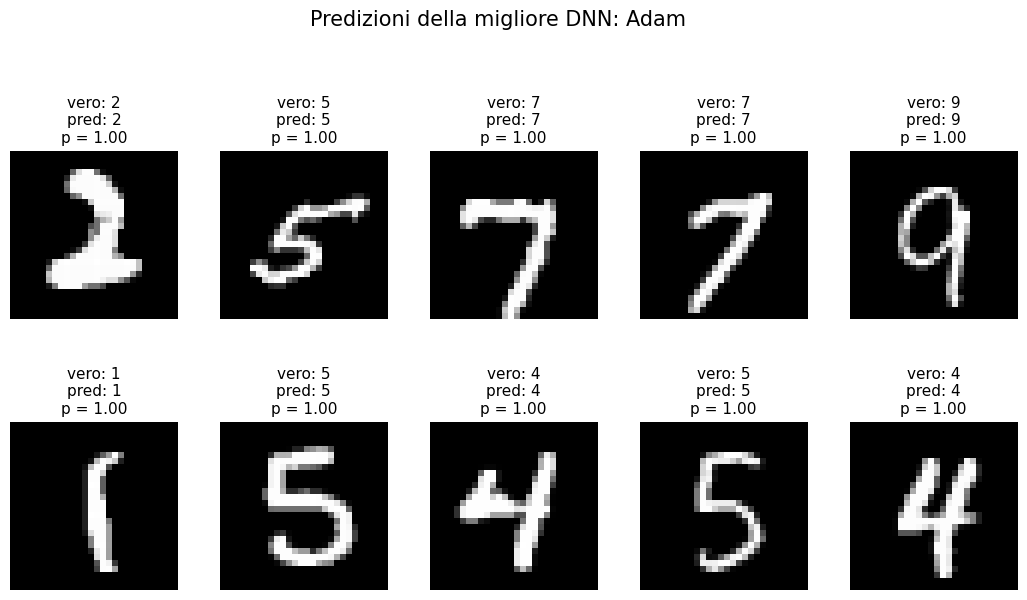

In [7]:
# Scelgo il modello DNN con la migliore accuracy sul test set.
miglior_nome_DNN = risultati_DNN.sort_values("test_accuracy", ascending=False).iloc[0]["ottimizzatore"]

# Recupero dal dizionario il modello già addestrato con quell'ottimizzatore.
miglior_modello_DNN = models_DNN[miglior_nome_DNN]

print("Migliore DNN secondo la test accuracy:", miglior_nome_DNN)

# Creo un generatore casuale fissando il seed.
rng = np.random.default_rng(seed)

# Estraggo 10 indici casuali dal test set, senza ripetizioni.
indici = rng.choice(len(X_test_DNN), size=10, replace=False)

# Recupero le immagini originali 28x28, utili per la visualizzazione.
immagini = X_test_raw[indici]

# Etichette vere delle immagini selezionate.
labels_veri = y_test[indici]

# Calcolo le predizioni della migliore DNN sulle 10 immagini selezionate.
predizioni = miglior_modello_DNN.predict(X_test_DNN[indici], verbose=0)

# La classe predetta è quella con probabilità massima.
labels_predetti = np.argmax(predizioni, axis=1)

# La confidenza è la probabilità assegnata alla classe predetta.
confidenze = np.max(predizioni, axis=1)

# Creo una griglia 2x5 per mostrare le 10 immagini.
fig, axes = plt.subplots(2, 5, figsize=(13, 7))
axes = axes.ravel()

for i, ax in enumerate(axes):

    ax.imshow(immagini[i], cmap="gray")
    ax.set_title(
        f"vero: {labels_veri[i]}\n"
        f"pred: {labels_predetti[i]}\n"
        f"p = {confidenze[i]:.2f}",
        fontsize=11
    )

    ax.axis("off")

fig.suptitle(f"Predizioni della migliore DNN: {miglior_nome_DNN}", fontsize=15)
fig.subplots_adjust(wspace=0.25, top=0.82)
plt.show()

Le dieci immagini scelte dal test set vengono classificate tutte correttamente dalla migliore DNN. È un buon controllo qualitativo: il modello non raggiunge solo una buona accuracy media, ma riesce anche a riconoscere esempi concreti di cifre MNIST con confidenza molto alta.

Questo risultato non va però interpretato come una verifica completa del modello, perché si tratta solo di dieci immagini casuali. La valutazione quantitativa resta quella fatta sull'intero test set. La figura serve soprattutto a mostrare in modo visivo che le predizioni della DNN sono coerenti con le cifre mostrate.


# Esercizio 12.2 - CNN

Nella seconda parte sostituisco la rete fully connected con una CNN. La differenza principale è che ora l'input non viene appiattito: ogni immagine mantiene la forma $28 \times 28 \times 1$. Questo permette alla rete di sfruttare la vicinanza tra pixel e di imparare filtri locali.

La rete contiene due blocchi convoluzionali. Ogni blocco usa una convoluzione per estrarre feature locali e un max pooling per ridurre la dimensione spaziale. Dopo questi layer, uso `Flatten` per trasformare le mappe di attivazione in un vettore e concludo con layer densi e softmax finale.

Mi aspetto che la CNN sia più efficace della DNN, non perché abbia semplicemente più layer, ma perché la sua architettura è più coerente con la natura del dato.


## Architettura CNN

La prima convoluzione applica 16 filtri diversi all'immagine in ingresso. Ogni filtro scorre sull'immagine e cerca un certo tipo di caratteristica locale, ad esempio un bordo, una curva o una piccola combinazione di pixel. Il risultato prodotto da ciascun filtro è una mappa di attivazione, cioè una nuova immagine che indica in quali zone il filtro ha trovato con maggiore intensità la caratteristica che sta cercando.

In questo senso, dire che la prima convoluzione produce 16 mappe di attivazione significa che la rete non costruisce una sola immagine trasformata, ma 16 rappresentazioni diverse della stessa cifra. Ognuna mette in evidenza aspetti differenti dell'input. La seconda convoluzione lavora poi su queste mappe e produce 32 nuove mappe di attivazione, quindi una rappresentazione ancora più ricca e astratta.

Uso `padding="same"` per mantenere invariata la dimensione spaziale dopo la convoluzione: se l'immagine entra con dimensione $28 \times 28$, anche l'uscita della convoluzione resta $28 \times 28$, a parte il numero di canali, cioè di mappe prodotte. I layer di `MaxPooling2D`, invece, riducono la dimensione spaziale: con un pooling $2 \times 2$, altezza e larghezza vengono dimezzate. Questo rende la rappresentazione più compatta e riduce il numero di parametri nelle parti successive della rete. In questo modo la rete riduce gradualmente la quantità di dati, conservando però le informazioni più rilevanti per la classificazione.

Anche qui uso dropout per limitare l'overfitting, soprattutto nella parte finale fully connected.

In [8]:
input_shape = (img_rows, img_cols, 1)

def crea_CNN():
    model = Sequential(name="mnist_CNN")
    model.add(Input(shape=input_shape))

    model.add(Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same", name="conv_1"))
    model.add(MaxPooling2D(pool_size=(2, 2), name="pool_1"))
    model.add(Dropout(0.25, name="dropout_1"))

    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", name="conv_2"))
    model.add(MaxPooling2D(pool_size=(2, 2), name="pool_2"))
    model.add(Dropout(0.25, name="dropout_2"))

    model.add(Flatten(name="flatten"))
    model.add(Dense(64, activation="relu", name="dense_1"))
    model.add(Dropout(0.5, name="dropout_3"))
    model.add(Dense(num_classes, activation="softmax", name="softmax"))

    return model


model_CNN = crea_CNN()
model_CNN.summary()

Model: "mnist_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

## Training della CNN

Dopo aver definito l'architettura, compilo la CNN con `categorical_crossentropy` e `Adam`. La scelta di `Adam` è naturale perché nella parte precedente ha dato il comportamento più stabile tra gli ottimizzatori provati.

Uso immagini nel formato $28 \times 28 \times 1$, quindi la CNN lavora direttamente sulla struttura bidimensionale dei dati. Alla fine valuto il modello sia sul training set sia sul test set. Il confronto tra queste due quantità permette di capire se la rete sta generalizzando bene oppure se sta imparando troppo specificamente il training set.


In [9]:
batch_size_CNN = 128
epochs_CNN = 20

model_CNN.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"],
)

history_CNN = model_CNN.fit(
    X_train_CNN,
    Y_train,
    batch_size=batch_size_CNN,
    epochs=epochs_CNN,
    validation_data=(X_test_CNN, Y_test),
    shuffle=True,
    verbose=0,
)

train_loss_CNN, train_accuracy_CNN = model_CNN.evaluate(X_train_CNN, Y_train, verbose=0)
test_loss_CNN, test_accuracy_CNN = model_CNN.evaluate(X_test_CNN, Y_test, verbose=0)

print("CNN train loss:    ", train_loss_CNN)
print("CNN train accuracy:", train_accuracy_CNN)
print("CNN test loss:     ", test_loss_CNN)
print("CNN test accuracy: ", test_accuracy_CNN)

CNN train loss:     0.014718987978994846
CNN train accuracy: 0.9953833222389221
CNN test loss:      0.02206771820783615
CNN test accuracy:  0.9921000003814697


## Grafici di loss e accuracy per la CNN

Per la CNN guardo gli stessi indicatori usati per la DNN: loss e accuracy su training e validation/test. Questo rende più semplice confrontare i due modelli e capire se la rete convoluzionale porta un miglioramento reale.


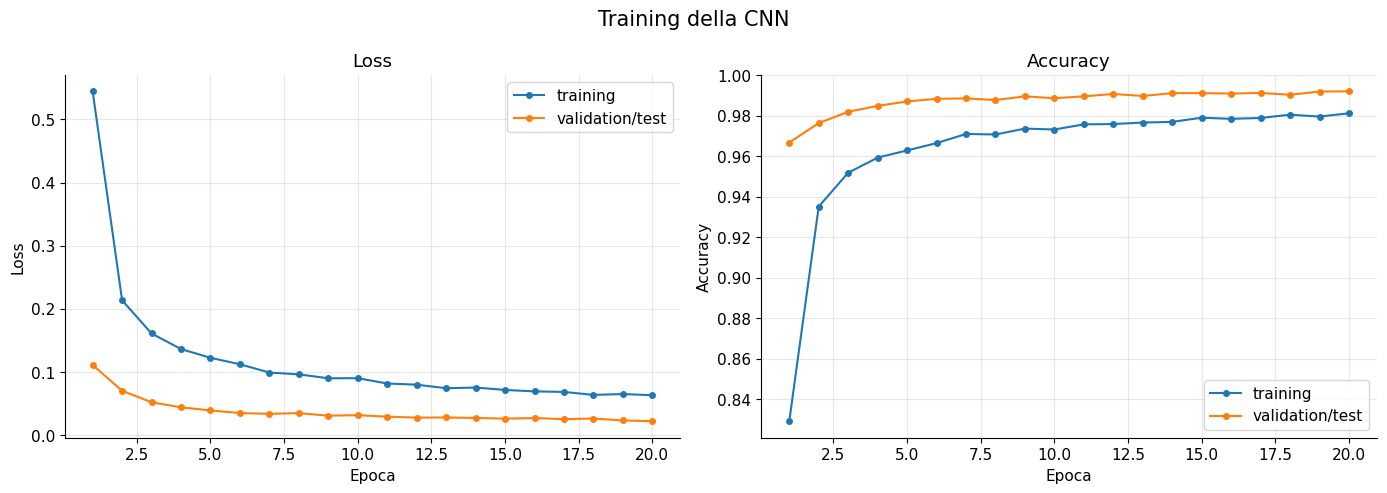

In [10]:
def plot_storia_singola(history, titolo):
    epoche = np.arange(1, len(history.history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epoche, history.history["loss"], marker="o", markersize=4, label="training")
    axes[0].plot(epoche, history.history["val_loss"], marker="o", markersize=4, label="validation/test")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epoche, history.history["accuracy"], marker="o", markersize=4, label="training")
    axes[1].plot(epoche, history.history["val_accuracy"], marker="o", markersize=4, label="validation/test")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoca")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(titolo, fontsize=15)
    fig.tight_layout()
    plt.show()


plot_storia_singola(history_CNN, "Training della CNN")

I grafici mostrano che la CNN converge molto rapidamente. La loss cala soprattutto nelle prime epoche e poi continua a diminuire più lentamente, mentre l'accuracy sui dati di validation cresce subito e tende a stabilizzarsi vicino al 99%.

La validation/test accuracy risulta leggermente superiore alla training accuracy. Questo non è necessariamente un problema. Durante il training il dropout è attivo e rende il compito più difficile, mentre durante la validazione la rete usa tutti i neuroni. Inoltre, l'accuracy di training mostrata durante `fit` viene calcolata mentre i pesi stanno ancora cambiando nel corso dell'epoca.

Non si vede un overfitting evidente: la validation/test loss resta bassa e non mostra una crescita sistematica nelle ultime epoche. Questo indica che la CNN non sta solo memorizzando il training set, ma sta imparando feature utili anche per immagini non viste.


## Confronto finale tra migliore DNN e CNN

A questo punto confronto la migliore DNN ottenuta nell'esercizio 12.1 con la CNN. Il confronto più significativo è quello sul test set, perché entrambi i modelli hanno già visto il training set durante l'addestramento.


In [11]:
risultati_CNN = pd.DataFrame([{
    "modello": "CNN",
    "train_loss": train_loss_CNN,
    "train_accuracy": train_accuracy_CNN,
    "test_loss": test_loss_CNN,
    "test_accuracy": test_accuracy_CNN,
}])

migliore_DNN_riga = risultati_DNN.sort_values("test_accuracy", ascending=False).iloc[0]

confronto_finale = pd.DataFrame([
    {
        "modello": f"DNN ({migliore_DNN_riga['ottimizzatore']})",
        "train_loss": migliore_DNN_riga["train_loss"],
        "train_accuracy": migliore_DNN_riga["train_accuracy"],
        "test_loss": migliore_DNN_riga["test_loss"],
        "test_accuracy": migliore_DNN_riga["test_accuracy"],
    },
    {
        "modello": "CNN",
        "train_loss": train_loss_CNN,
        "train_accuracy": train_accuracy_CNN,
        "test_loss": test_loss_CNN,
        "test_accuracy": test_accuracy_CNN,
    },
])

confronto_finale

,modello,train_loss,train_accuracy,test_loss,test_accuracy
0,DNN (Adam),0.009407,0.997133,0.115088,0.9812
1,CNN,0.014719,0.995383,0.022068,0.9921


La tabella conferma il vantaggio della CNN. La migliore DNN è quella addestrata con `Adam`, ma la CNN ottiene una test accuracy più alta e soprattutto una test loss molto più bassa. Questo secondo dato è utile perché indica che le predizioni corrette della CNN sono, in media, anche più ben calibrate rispetto a quelle della DNN.

La differenza di accuracy può sembrare piccola perché MNIST è un dataset semplice e anche la DNN parte già da prestazioni alte. Però il miglioramento è coerente con la struttura del problema: per classificare immagini conviene mantenere l'informazione spaziale invece di appiattire subito tutti i pixel.


## Predizioni di esempio con la CNN

Mostro ora alcune predizioni della CNN su cifre del test set MNIST. Questa visualizzazione serve come controllo qualitativo: oltre al valore medio dell'accuracy, è utile vedere direttamente che tipo di immagini vengono classificate correttamente e con quale confidenza.


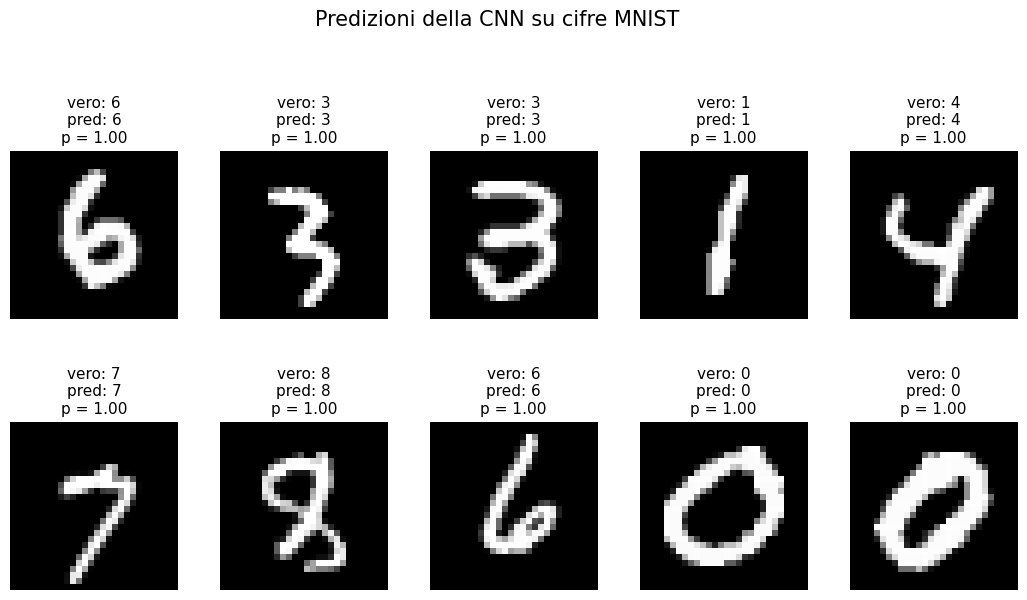

In [12]:
rng = np.random.default_rng(seed + 1)
indici = rng.choice(len(X_test_CNN), size=10, replace=False)

immagini = X_test_CNN[indici]
labels_veri = y_test[indici]

predizioni = model_CNN.predict(immagini, verbose=0)
labels_predetti = np.argmax(predizioni, axis=1)
confidenze = np.max(predizioni, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 7))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.imshow(immagini[i, :, :, 0], cmap="gray")
    ax.set_title(
        f"vero: {labels_veri[i]}\n"
        f"pred: {labels_predetti[i]}\n"
        f"p = {confidenze[i]:.2f}",
        fontsize=11
    )
    ax.axis("off")

fig.suptitle("Predizioni della CNN su cifre MNIST", fontsize=15)

# Più spazio tra le due righe e più margine sopra per il titolo.
fig.subplots_adjust(wspace=0.25, top=0.82)

plt.show()

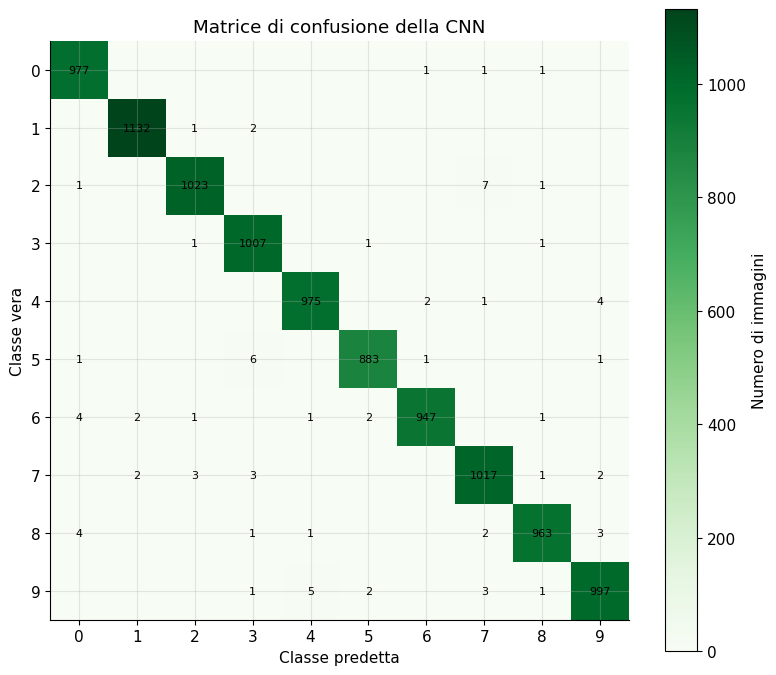

In [13]:
predizioni_test_CNN = model_CNN.predict(X_test_CNN, verbose=0)
labels_predetti_test_CNN = np.argmax(predizioni_test_CNN, axis=1)

matrice_confusione = np.zeros((num_classes, num_classes), dtype=int)

for vero, predetto in zip(y_test, labels_predetti_test_CNN):
    matrice_confusione[vero, predetto] += 1

plt.figure(figsize=(8, 7))
plt.imshow(matrice_confusione, cmap="Greens")
plt.title("Matrice di confusione della CNN")
plt.xlabel("Classe predetta")
plt.ylabel("Classe vera")
plt.xticks(np.arange(num_classes))
plt.yticks(np.arange(num_classes))
plt.colorbar(label="Numero di immagini")


for i in range(num_classes):
    for j in range(num_classes):
        valore = matrice_confusione[i, j]
        if valore > 0:
            plt.text(j, i, str(valore), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Commento sui risultati della CNN

La CNN ottiene una test accuracy più alta della migliore DNN. Questo è il risultato principale dell'esercizio 12.2 ed è coerente con quello che ci si aspetta: la CNN conserva la struttura spaziale dell'immagine e impara filtri locali, mentre la DNN lavora su un vettore di pixel e quindi non sfrutta direttamente la geometria del problema.

Un altro punto importante è la loss sul test set. Anche quando le accuracy sono entrambe alte, la loss della CNN è sensibilmente più bassa. Questo significa che la CNN non solo classifica correttamente più immagini, ma tende anche ad assegnare probabilità più coerenti alle classi corrette.

La matrice di confusione permette di controllare quali cifre vengono confuse più spesso. Gli errori residui sono pochi e riguardano in genere cifre con forme simili o scritte in modo ambiguo, come coppie del tipo 4/9, 3/5 oppure 2/7. Questo è ragionevole: anche per un osservatore umano alcune cifre MNIST possono non essere completamente nette.

Nel complesso la CNN rappresenta un miglioramento rispetto alla DNN. La differenza non è enorme in termini assoluti, perché MNIST è già un dataset semplice, ma è chiara sia nei grafici sia nei valori finali di test accuracy e test loss.


# Esercizio 12.3 - Cifre personali

Nell'ultima parte provo la CNN su dieci immagini create da me, una per ogni cifra. Questo è un test più realistico rispetto al test set MNIST, perché le mie cifre possono avere tratto, spessore, centratura e stile diversi da quelli presenti nel dataset di training.


## Caricamento e preprocessing delle cifre personali

Per testare la rete su immagini diverse da quelle di MNIST, ho preparato dieci cifre scritte a mano. Le immagini vanno salvate nella cartella `HANDWRITTEN_DIGITS` con nomi semplici:

`0.png`, `1.png`, ..., `9.png`.

Nel codice le immagini vengono caricate in scala di grigi, ridimensionate a $28 \times 28$ pixel e normalizzate in modo che i valori dei pixel siano compresi tra $0$ e $1$, come per il dataset MNIST.

In [14]:
cartella_cifre = Path("HANDWRITTEN_DIGITS")
percorsi_cifre = [cartella_cifre / f"{i}.png" for i in range(num_classes)]

for percorso in percorsi_cifre:
    assert percorso.exists(), f"Manca il file: {percorso}"


def carica_cifra_personale(percorso):
    immagine = Image.open(percorso).convert("L").resize((img_cols, img_rows))
    matrice = np.asarray(immagine).astype("float32") / 255.0

    return matrice


immagini_personali_2D = np.array([carica_cifra_personale(percorso) for percorso in percorsi_cifre])
immagini_personali_CNN = immagini_personali_2D.reshape(num_classes, img_rows, img_cols, 1)
labels_personali = np.arange(num_classes)

print("Shape immagini personali:", immagini_personali_CNN.shape)

Shape immagini personali: (10, 28, 28, 1)


## Predizione delle cifre personali con la CNN

Uso la CNN addestrata su MNIST per classificare le dieci cifre personali. In tabella riporto il file, la label attesa, la label predetta, la confidenza della predizione e se la classificazione è corretta.


In [15]:
predizioni_personali = model_CNN.predict(immagini_personali_CNN, verbose=0)
labels_predetti_personali = np.argmax(predizioni_personali, axis=1)
confidenze_personali = np.max(predizioni_personali, axis=1)

risultati_personali = pd.DataFrame({
    "file": [percorso.name for percorso in percorsi_cifre],
    "label_attesa": labels_personali,
    "label_predetta": labels_predetti_personali,
    "confidenza": confidenze_personali,
    "corretta": labels_personali == labels_predetti_personali,
})

accuracy_personale = np.mean(labels_personali == labels_predetti_personali)

print("Accuracy sulle cifre personali:", accuracy_personale)
risultati_personali

Accuracy sulle cifre personali: 0.8


,file,label_attesa,label_predetta,confidenza,corretta
0,0.png,0,0,0.999903,True
1,1.png,1,1,0.971800,True
2,2.png,2,2,0.999994,True
3,3.png,3,3,1.000000,True
4,4.png,4,4,0.998284,True
5,5.png,5,5,0.999997,True
6,6.png,6,5,0.854784,False
7,7.png,7,7,0.936387,True
8,8.png,8,3,0.929220,False
9,9.png,9,9,0.995280,True


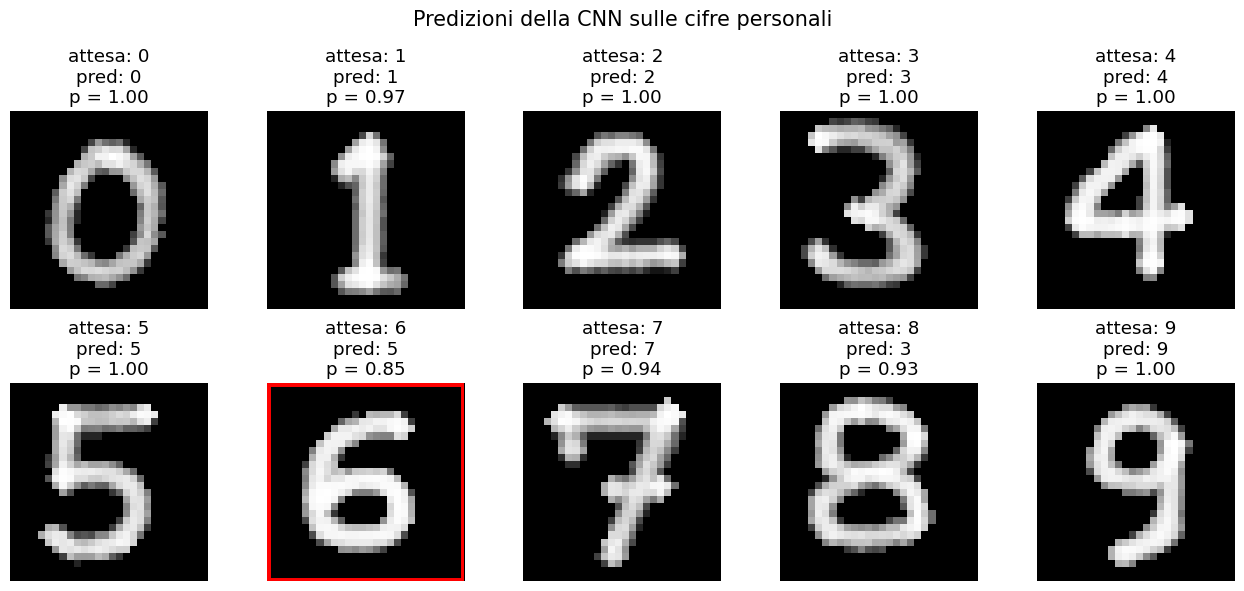

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.imshow(immagini_personali_2D[i], cmap="gray")
    ax.set_title(
        f"attesa: {labels_personali[i]}\n"
        f"pred: {labels_predetti_personali[i]}\n"
        f"p = {confidenze_personali[i]:.2f}"
    )
    # Evidenzio con un contorno rosso l'immagine della cifra 6.
    if labels_personali[i] == 6:
        ax.add_patch(
            plt.Rectangle(
                (-0.5, -0.5),
                img_cols,
                img_rows,
                fill=False,
                edgecolor="red",
                linewidth=5
            )
        )
        
    ax.axis("off")



fig.subplots_adjust(hspace=0.55, wspace=0.25, top=0.85)
fig.suptitle("Predizioni della CNN sulle cifre personali", fontsize=15)
fig.tight_layout()
plt.show()

## Commento sulle cifre personali

Le cifre personali sono più difficili del test set MNIST, perché non provengono esattamente dalla stessa distribuzione dei dati usati per il training. Anche se sono sempre cifre da $0$ a $9$, possono avere spessore diverso, essere meno centrate, avere una forma meno regolare oppure semplicemente essere scritte con uno stile diverso. Per questo motivo non mi aspetto necessariamente una accuracy vicina a quella ottenuta sul test set MNIST.

Nel mio caso la CNN riconosce correttamente 9 cifre su 10. L'unico errore riguarda la cifra $6$, che viene classificata come $5$. L'errore è abbastanza comprensibile: se il tratto del $6$ non è molto chiuso o se la parte superiore è più simile a quella di un $5$, la rete può interpretare l'immagine in modo diverso da come la interpretiamo noi visivamente.

Un aspetto da tenere presente è che la probabilità prodotta dalla softmax non va letta come una garanzia assoluta di correttezza. La rete può assegnare una confidenza alta anche a una predizione sbagliata, soprattutto quando l'immagine in ingresso è diversa da quelle viste durante il training.

Questa prova mostra bene il comportamento del modello: la CNN funziona molto bene su immagini simili a MNIST, ma può perdere accuratezza quando cambia lo stile della scrittura.

# Conclusioni

In questa esercitazione ho confrontato due approcci per il riconoscimento di cifre MNIST. La DNN fully connected è una buona baseline: anche trattando le immagini come vettori di $784$ pixel riesce a ottenere un'accuracy elevata. Il confronto tra ottimizzatori mostra però che la scelta del metodo di training è importante: `SGD` converge più lentamente, mentre `Adam` è risultato il più efficace e stabile tra quelli provati.

La CNN migliora il risultato perché usa un'architettura più adatta alle immagini. I layer convoluzionali sfruttano la località dei pixel e imparano feature spaziali, mentre il pooling riduce progressivamente la dimensione delle mappe mantenendo l'informazione rilevante. Nei risultati ottenuti, la CNN ha una test accuracy superiore e una test loss più bassa rispetto alla migliore DNN.

Il test sulle cifre personali è stato il più severo. La rete, addestrata su MNIST, non riconosce tutte le cifre disegnate da me. Questo non contraddice il buon risultato sul test set: mostra piuttosto che il modello generalizza bene quando i dati sono simili a quelli di training, ma può sbagliare quando cambia lo stile dell'immagine. È un esempio concreto del fatto che una buona accuracy su un dataset standard non garantisce automaticamente la stessa prestazione su dati reali o prodotti in modo diverso.

Nel complesso, l'esercizio mostra perché le CNN siano più adatte delle reti dense per problemi di classificazione di immagini: non si limitano ad aumentare il numero di parametri, ma incorporano direttamente una proprietà importante del dato, cioè la sua struttura spaziale.
